In [150]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [151]:
# experiment_dir = Path("/dcs/large/u1508153/misdro/kl_newsvendor_exp_1d")
experiment_dir = Path("/dcs/large/u1508153/misdro/kl_newsvendor_exp_1d")

assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
for _, row in all_results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "kl_dro_bas":
        num_total_samples.append(row["num_likelihood_samples"])
all_results_df["num_total_samples"] = num_total_samples

In [152]:
# NOTE filter by DGP
results_df = all_results_df.loc[all_results_df["dgp"] == "contaminated_exp"]

# NOTE filter by contamination and num_observations
results_df = results_df.loc[results_df["num_observations"] == 20]
results_df = results_df.loc[results_df["contamination"] == 0.2]

# NOTE filter out when log_partition_constant G is less than epsilon
results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

results_df

mean_cost     var_cost  \
uuid                                 replication                            
00df49f1-611e-4809-97cf-d62ee692f248 0             89.331098   702.402977   
                                     1             85.462621   618.399858   
                                     2             72.785190   727.762328   
                                     3             77.566980   694.299650   
                                     4             98.387778   685.385724   
...                                                      ...          ...   
c09c8b84-22c5-4666-bdca-c4ae8abdde19 195          186.745573  1023.503374   
                                     196          221.404254   608.042652   
                                     197          192.804654  1309.403211   
                                     198          186.476652  1060.192557   
                                     199          170.016665   630.800728   

                                                              solution  \
uuid                                 replication                         
00df49f1-611e-4809-97cf-d62ee692f248 0            [40.033748437579646]   
                                     1             [36.72142035767386]   
                                     2            [33.578145636133506]   
                                     3            [36.255761516267725]   
                                     4             [42.29241650378352]   
...                                                                ...   
c09c8b84-22c5-4666-bdca-c4ae8abdde19 195           [72.37764486617732]   
                                     196           [81.40492813700597]   
                                     197           [76.33513157989626]   
                                     198           [72.78463045662623]   
                                     199           [66.19608957405424]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
00df49f1-611e-4809-97cf-d62ee692f248 0            0.000486         0.000108   
                                     1            0.000771         0.000176   
                                     2            0.000723         0.000191   
                                     3            0.000534         0.000166   
                                     4            0.000650         0.000162   
...                                                    ...              ...   
c09c8b84-22c5-4666-bdca-c4ae8abdde19 195          0.000665         0.003790   
                                     196          0.000586         0.002459   
                                     197          0.000587         0.003252   
                                     198          0.000613         0.002634   
                                     199          0.000422         0.002010   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
00df49f1-611e-4809-97cf-d62ee692f248 0                  0.000046    0.664781   
                                     1                  0.000057    0.492342   
                                     2                  0.000087    0.442650   
                                     3                  0.000063    0.464548   
                                     4                  0.000056    0.437959   
...                                                          ...         ...   
c09c8b84-22c5-4666-bdca-c4ae8abdde19 195                0.000196    0.490506   
                                     196                0.000149    0.474434   
                                     197                0.000191    0.549498   
                                     198                0.000170    0.480604   
                                     199                0.000135    0.315178   

                 

In [153]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior", "num_posterior_samples", "num_likelihood_samples"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    # "solution": ["mean", "var"],
})
agg_df

mean_cost  \
                                                                                                            mean   
algorithm  dgp              epsilon inference posterior num_posterior_samples num_likelihood_samples               
kl_bdro    contaminated_exp 0.001   bayes     gamma     30                    30                       83.806006   
                            0.002   bayes     gamma     30                    30                       84.977009   
                            0.005   bayes     gamma     30                    30                       87.376640   
                            0.010   bayes     gamma     30                    30                       90.238460   
                            0.020   bayes     gamma     30                    30                       94.385854   
                            0.030   bayes     gamma     30                    30                       97.546491   
                            0.040   bayes     gamma     30                    30                      100.383531   
                            0.050   bayes     gamma     30                    30                      102.909746   
                            0.060   bayes     gamma     30                    30                      105.148312   
                            0.070   bayes     gamma     30                    30                      107.321924   
                            0.080   bayes     gamma     30                    30                      109.320772   
                            0.090   bayes     gamma     30                    30                      111.261138   
                            0.100   bayes     gamma     30                    30                      113.100144   
                            0.150   bayes     gamma     30                    30                      121.239033   
                            0.200   bayes     gamma     30                    30                      128.210787   
                            0.250   bayes     gamma     30                    30                      134.365480   
                            0.300   bayes     gamma     30                    30                      139.924651   
                            0.400   bayes     gamma     30                    30                      149.812364   
                            0.500   bayes     gamma     30                    30                      158.493280   
                            0.600   bayes     gamma     30                    30                      166.397402   
                            0.700   bayes     gamma     30                    30                      173.617290   
                            0.800   bayes     gamma     30                    30                      180.106619   
                            0.900   bayes     gamma     30                    30                      185.991014   
                            1.000   bayes     gamma     30                    30                      191.386550   
kl_dro_bas contaminated_exp 0.030   bayes     gamma     1                     900                      84.274168   
                            0.040   bayes     gamma     1                     900                      88.524841   
                            0.050   bayes     gamma     1                     900                      91.773700   
                            0.060   bayes     gamma     1                     900                      94.351266   
                            0.070   bayes     gamma     1                     900                      96.683666   
                            0.080   bayes     gamma     1                     900                      98.891918   
                            0.090   bayes     gamma     1                     900                     100.917121   
                            0.100   bayes     gamma     1                     900                     102.723813   
                            0.150   bayes  

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


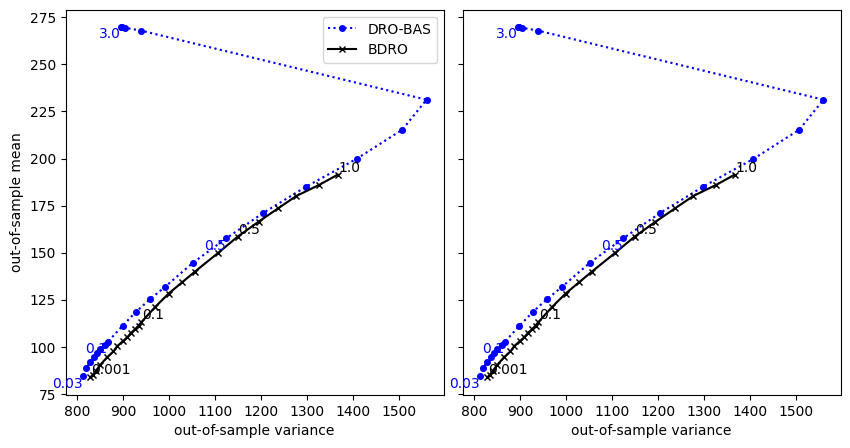

In [154]:
from mis_dro.plot import mean_variance_plot, algorithm_style, AlgorithmColor

from enum import StrEnum

def mean_variance_plot(
    axis,
    df: pd.DataFrame,
    is_labelled: bool = True,
    **kwargs,
) -> None:
    posterior_var = df["var_cost"]["mean"] + df["mean_cost"]["var"]

    # plot mean-variance trade-off
    epsilon_list = list(df.index.get_level_values("epsilon"))
    axis.plot(posterior_var, df["mean_cost"]["mean"], **kwargs, markersize=4)
    # axis.scatter(posterior_var, df["mean_cost"]["mean"], s=100*np.sqrt(np.array(epsilon_list)), **kwargs)
    if is_labelled:
        
        for i, epsilon in enumerate(epsilon_list):
            # if i % 4 == 0:

            if i == 0 or i == len(epsilon_list) - 1 or epsilon in (0.1, 0.5):
                # if line is blue then put text on bottom left
                if kwargs["color"] == AlgorithmColor.kl_dro_bas:
                    ha = "right"
                    va = "top"
                    # offset = -1 if i==0 or i == len(epsilon_list) else -5
                    offset = -1

                # else if line is black then put text on top right
                elif kwargs["color"] == AlgorithmColor.kl_bdro:
                    ha = "left"
                    va = "bottom"
                    # offset = 1 if i==0 or i == len(epsilon_list) else 5
                    offset = 1

                axis.text(
                    posterior_var[:, :, epsilon, :].iloc[0] + offset,
                    df["mean_cost"]["mean"][:, :, epsilon, :].iloc[0],
                    epsilon,
                    ha=ha,
                    va=va,
                    color=kwargs["color"],
                )

class NiceNameDGP(StrEnum):
    normal = "Normal DGP"
    truncated_normal = "Truncated Normal DGP"

# NOTE if you want to visual only one DGP, then uncomment the below lines
# only_dgp = "normal"
# agg_df = agg_df.loc[:, only_dgp, :, :]

compare_col="algorithm"
gb_col="dgp"
likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")

# TOTAL_SAMPLES = [25, 100, 900, 2500]
# TOTAL_SAMPLES = [25, 100, 900]
TOTAL_SAMPLES = [900, 900]

nrows = len(agg_df.index.get_level_values("dgp").unique())
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[(
        (likelihood_sr == int(np.sqrt(total_samples))) & (posterior_sr == int(np.sqrt(total_samples)))
        | (likelihood_sr == total_samples) & (posterior_sr == 1)
    )]
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
    gb = df.groupby(gb_col)

    for k in range(len(TOTAL_SAMPLES)):
        if j == k:
            alpha = 1.0
            is_labelled = True
        else:
            alpha = 0.2
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                    group_df.index.get_level_values("inference"),
                    group_df.index.get_level_values("posterior"),
                )
            )
            if k == 0:
                axes[k].set_ylabel("out-of-sample mean")
                axes[k].legend()
            axes[k].set_xlabel("out-of-sample variance")

            # axes[i, k].set_title(f"{NiceNameDGP[group].value} with {n_total_samples_sqrt**2} samples")
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp, inference, posterior in index_set:
                style = algorithm_style(algorithm)
                line_label = ""
                if k == 0 and j == k:
                    line_label = style.pop("label")
                else:
                    style.pop("label")
                mean_variance_plot(axes[k], group_df.loc[algorithm, dgp, :np.inf, inference, posterior], **style, alpha=alpha, is_labelled=is_labelled, label=line_label)

fig.show()

## Solve time

In [155]:
results_df["is_warm_start"] = results_df.index.get_level_values("replication") == 0

# solve_time_df = results_df.groupby(["algorithm", "dgp", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="dgp").unstack(level="algorithm")
solve_time_df = results_df.groupby(["algorithm", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="algorithm").swaplevel(1,2, axis="columns")

solve_time_df


solve_time                                
algorithm                          kl_bdro kl_dro_bas   kl_bdro kl_dro_bas
                                      mean       mean       std        std
num_total_samples is_warm_start                                           
900               False           0.598469   0.400061  0.056424   0.064957
                  True            7.635349   0.606569  0.275755   0.027803

In [156]:
print(solve_time_df.to_latex())

\begin{tabular}{llrrrr}
\toprule
 &  & \multicolumn{4}{r}{solve_time} \\
 & algorithm & kl_bdro & kl_dro_bas & kl_bdro & kl_dro_bas \\
 &  & mean & mean & std & std \\
num_total_samples & is_warm_start &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{900} & False & 0.598469 & 0.400061 & 0.056424 & 0.064957 \\
 & True & 7.635349 & 0.606569 & 0.275755 & 0.027803 \\
\cline{1-6}
\bottomrule
\end{tabular}



# Constant $G(\tau_n)$ and expected KL

In [157]:

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_log_partition_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_log_partition_constant("normal_gamma", theta_posterior)

dgp = "multivariate_normal"
posterior = "normal_inverse_wishart"
num_observations = NUM_OBSERVATIONS
G_constant = []             # calculate the constant G
posterior_expected_kl = []  # assuming normal DGP, what is expectation under the posterior of the KL between the DGP and the likelihood?
prior_expected_kl = []      # assuming normal DGP, what is expectation under the prior of the KL between the DGP and the likelihood?
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)  # optimal solution

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_log_partition_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

ValueError: Dimension mismatch: array 'cov' is of shape (1, 1), but 'mean' is a vector of length 5.

In [ ]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.08892539135699731, 0.0022999465683889984)

In [ ]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.7442957726813, 0.0)

# Mean squared error between our solution and the solution under the DGP


In [ ]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 809.5869569415518, 16.31412063772674)

In [ ]:
def multivariate_digamma(a: float, p: int) -> float:
    """The multivariate digamma function of dimension p

    Notes:
        [1] https://search.r-project.org/CRAN/refmans/CholWishart/html/mvdigamma.html
        [2] https://en.wikipedia.org/wiki/Multivariate_gamma_function#Derivatives
    """
    return np.sum([sp.special.digamma(a + (1.0-i)/2.0) for i in range(p)])

def get_normal_inverse_wishart_G_constant(dim: int, kappa_post: float) -> float:
    """Returns the constant G(tau, nu) for the normal-inverse-Wishart"""
    term1 = -0.5 * dim * np.log(2)
    print(term1)
    term2 = - 0.5 * multivariate_digamma(0.5 * (kappa_post - dim - 2), dim)
    print(term2)
    term3 = dim / (2 * kappa_post)
    print(term3)
    term4 = dim * 0.5 * np.log(kappa_post - dim - 2)
    print(term4)
    # term5 = 0.5 * np.log(dim)
    # print(term5)
    return term1 + term2 + term3 + term4

In [ ]:
dim = 5
_, kappa_prior, _, _ = default_prior_params("normal_inverse_wishart", dim=dim)
kappa_post = kappa_prior +  20
kappa_prior, kappa_post

(13.0, 33.0)

In [ ]:
get_normal_inverse_wishart_G_constant(dim, kappa_post)

-1.7328679513998633
-6.208643562685282
0.07575757575757576
8.145241345053705


0.2794874067261359

In [167]:
x = np.array([2])
xi = np.array([[1], [3], [4]])
newsvendor_cost_cvxpy(x, xi).value.shape

(3,)

In [164]:
import cvxpy as cp
def newsvendor_cost_cvxpy_harita(x, xi):
    """Evaluate Newsvendor cost function with cvxpy
    Args:
        x: Demand decision variable
        xi: Realised random demand
    """
    return HOLDING_COST * cp.maximum(0, x - xi) + BACKORDER_COST * cp.maximum(0, xi - x)

In [166]:
newsvendor_cost_cvxpy_harita(x, xi).value.shape

(3, 1)